# Enhanced Clinical Data Analysis for Mortality Prediction

This notebook provides a comprehensive analysis of ICU patient data to predict mortality, including advanced visualization, model explanations, and fairness evaluations.

## 1. Setup and Configuration

In [58]:
# Import standard libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Import custom modules
import data_processing as dp
import visualization as viz
import modeling as mdl
import utils
import config

# Set visualization style
viz.set_visualization_style()
plt.style.use('seaborn-v0_8-whitegrid')

# Create directories if they don't exist
os.makedirs(config.RESULTS_DIR, exist_ok=True)
os.makedirs(config.MODELS_DIR, exist_ok=True)

## 2. Data Loading and Preprocessing

Number of samples	: 91713
Number of features	: 186


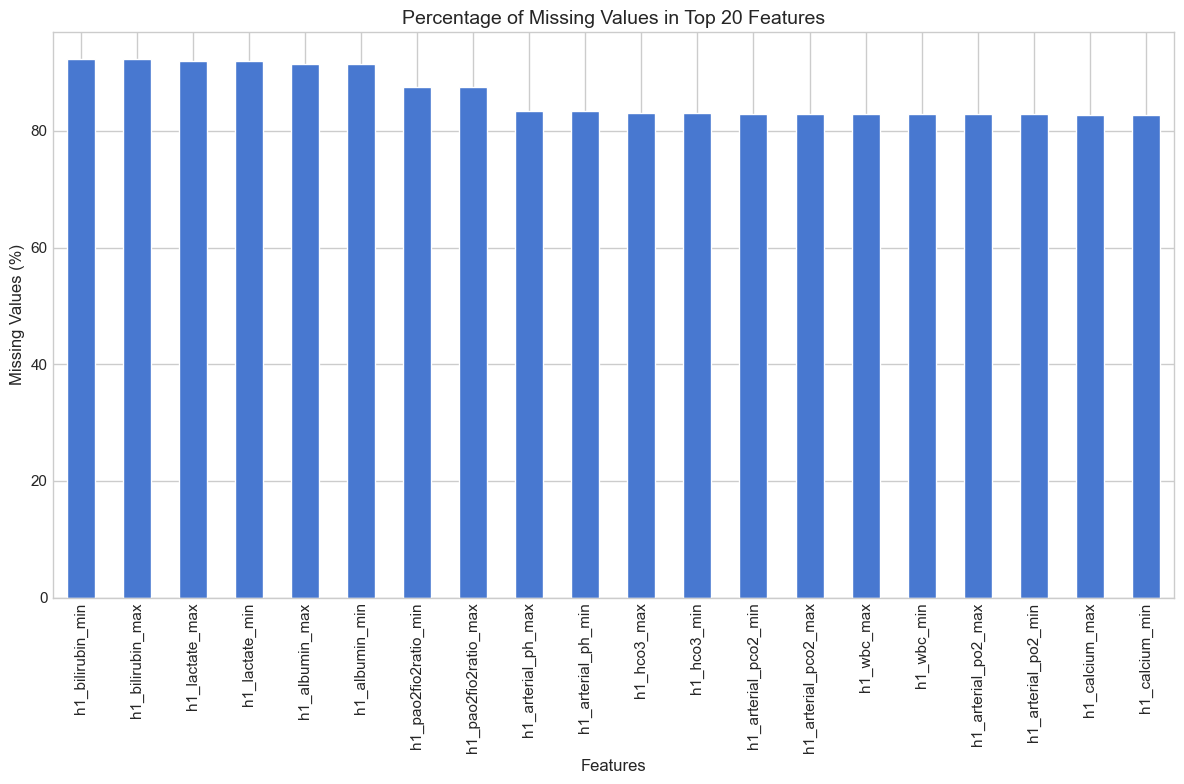

Training set size: (73370, 185)
Testing set size: (18343, 185)
Mortality rate in training set: 8.63%
Mortality rate in testing set: 8.63%
Number of columns with >80% missing values: 34
Number of numerical features: 143
Number of categorical features: 8
Processed data saved to results/processed_data.pkl

Basic statistics:
Number of training samples: 73370
Number of testing samples: 18343
Number of numerical features: 143
Number of categorical features: 8
Mortality rate in training set: 8.63%
Mortality rate in testing set: 8.63%


In [59]:
# Load data and data dictionary
df, description_dict = dp.load_data(config.DATA_DIR)
utils.print_dataset_info(df)

# Analyze missing values
missing_percentages, high_missing_cols = dp.analyze_missing_values(df)

# Plot missing values
viz.plot_missing_values(missing_percentages)

# Split data for modeling
X, y = dp.split_features_target(df, config.TARGET_COLUMN)
X_train, X_test, y_train, y_test = dp.create_train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

# Filter high missing columns and identify column types
X_train_filtered, X_test_filtered, high_missing_cols = dp.filter_high_missing_columns(
    X_train, X_test, threshold=config.MISSING_THRESHOLD_HIGH
)
numerical_cols, categorical_cols = dp.identify_column_types(X_train_filtered)

# Save processed data for later use
dp.save_processed_data(
    X_train_filtered, X_test_filtered, y_train, y_test,
    numerical_cols, categorical_cols, description_dict,
    os.path.join(config.RESULTS_DIR, 'processed_data.pkl')
)

## 3. Enhanced Data Exploration

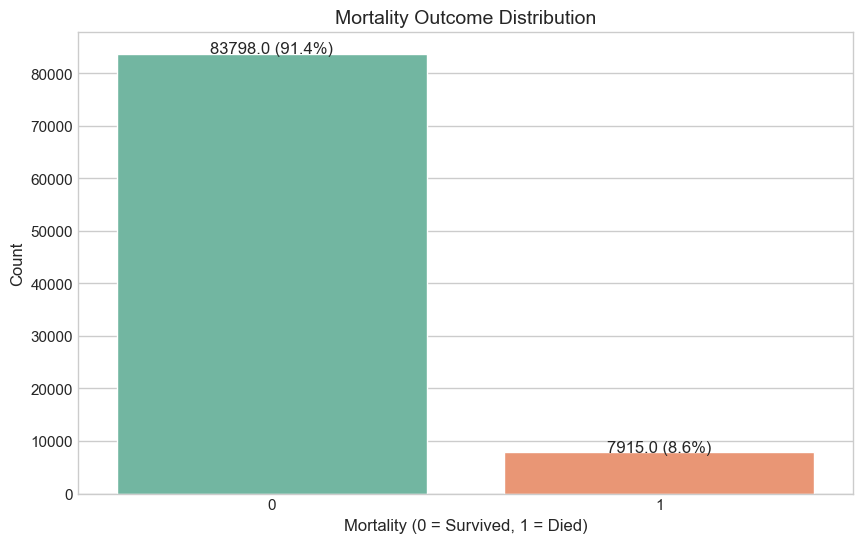

Dead: 7915 (8.63%) Survived: 83798 (91.37%) out of a total of 91713


In [60]:
# Visualize target variable distribution
viz.plot_target_distribution(df)

C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


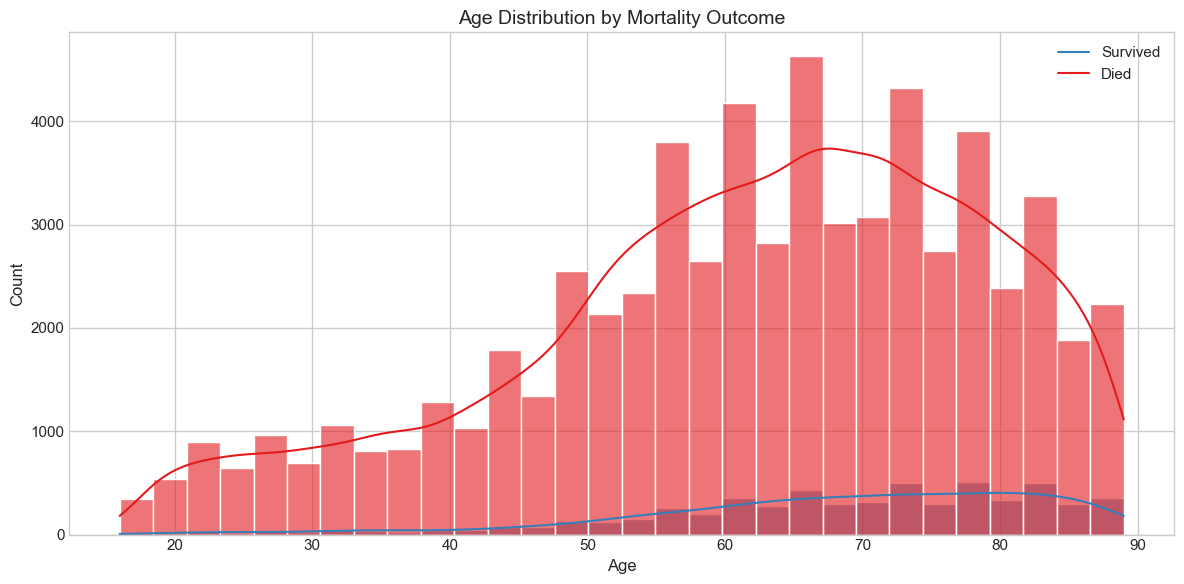

In [61]:
# Explore age distribution by mortality outcome
viz.plot_age_distribution_by_mortality(X_train_filtered, y_train)

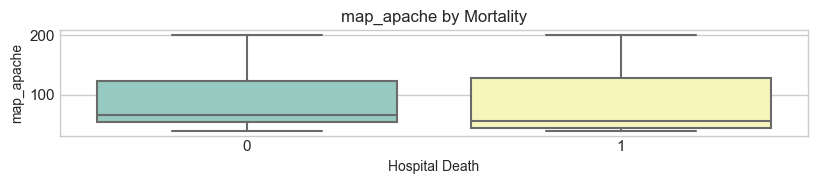

In [62]:
# Analyze key physiological parameters by mortality
physiological_vars = ['heart_rate', 'map_apache', 'resp_rate', 'temperature', 'wbc', 'creatinine']
viz.plot_physiological_vars_by_mortality(X_train_filtered, y_train, physiological_vars)

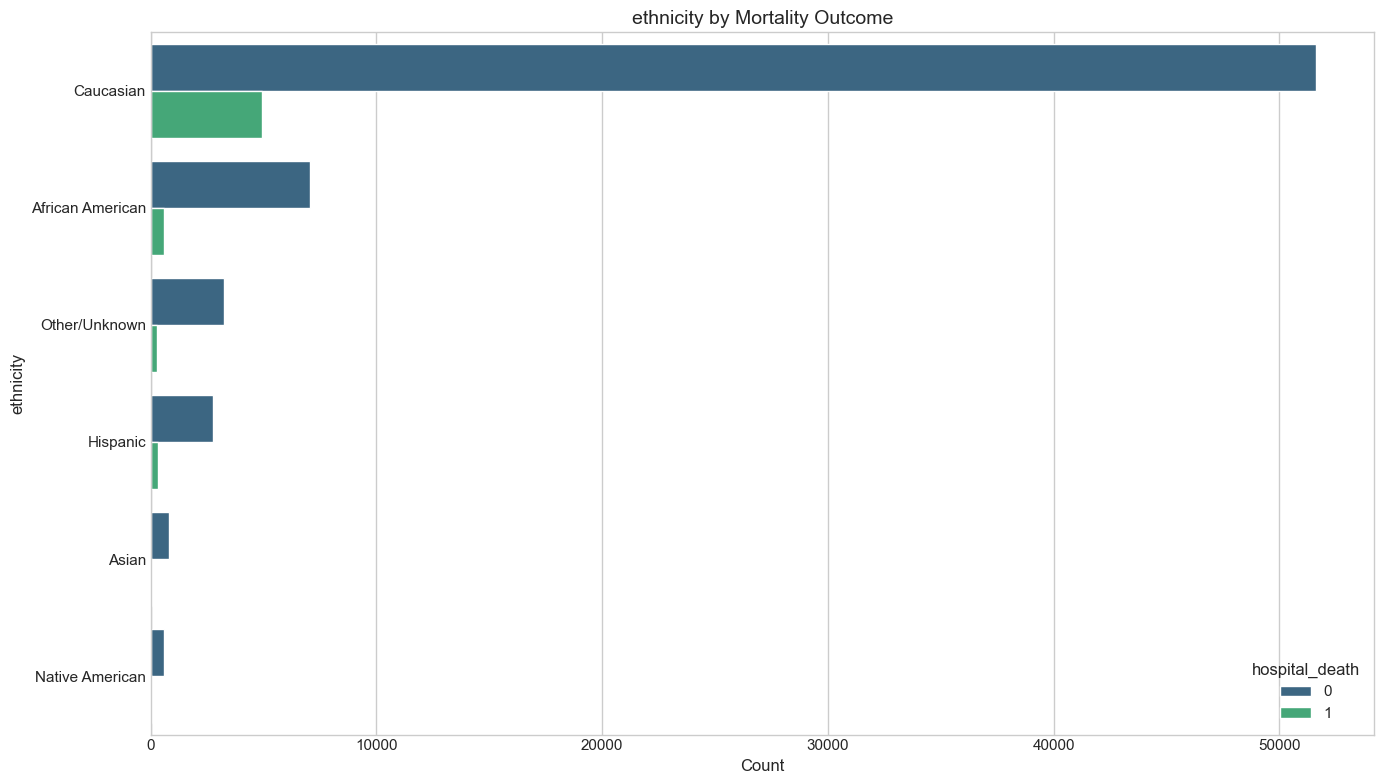

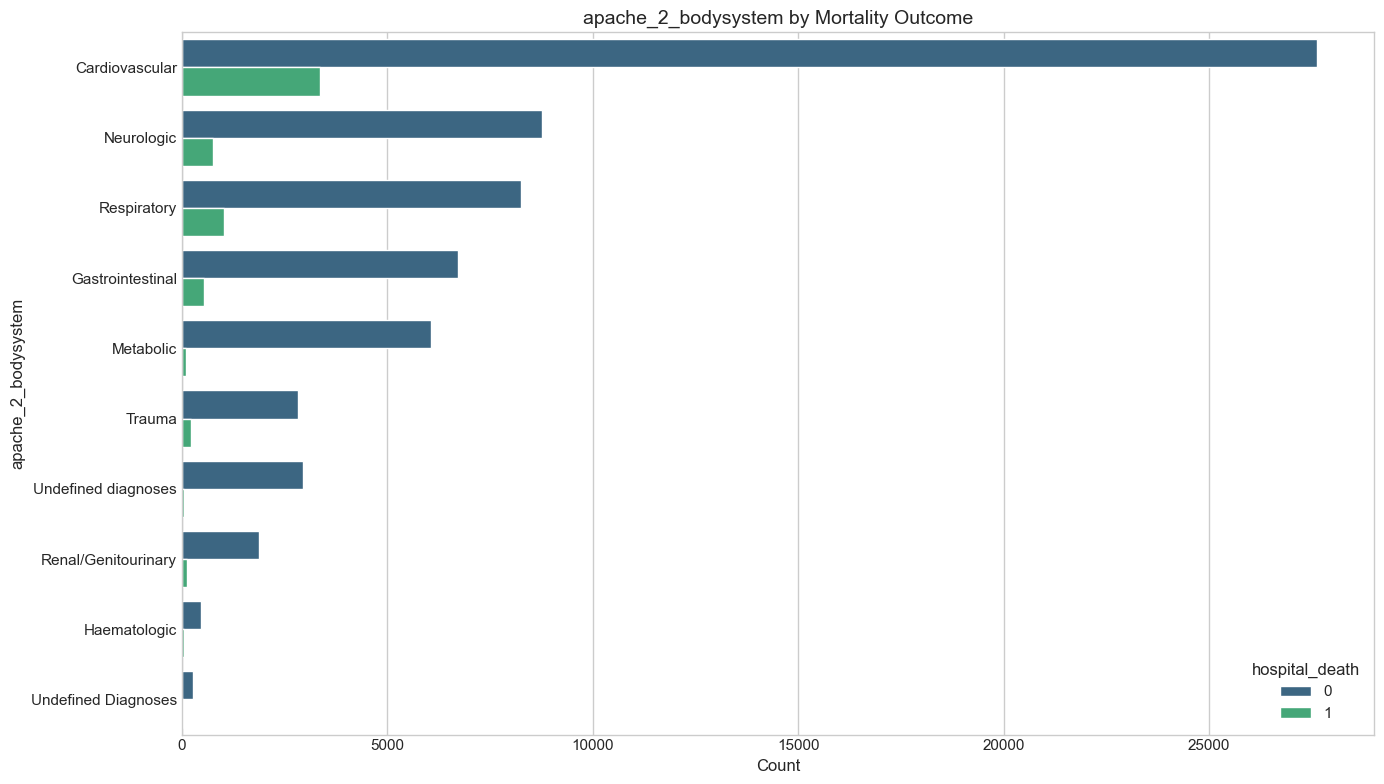

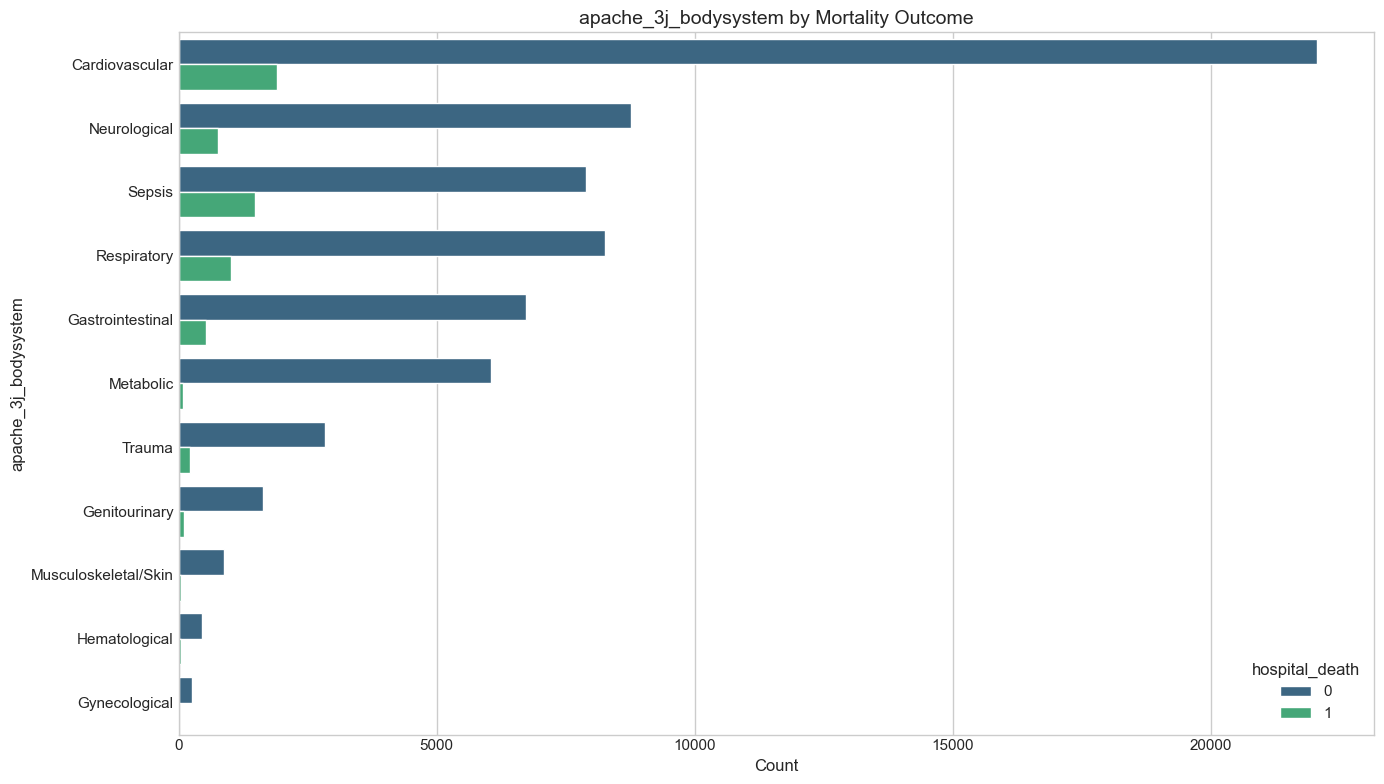

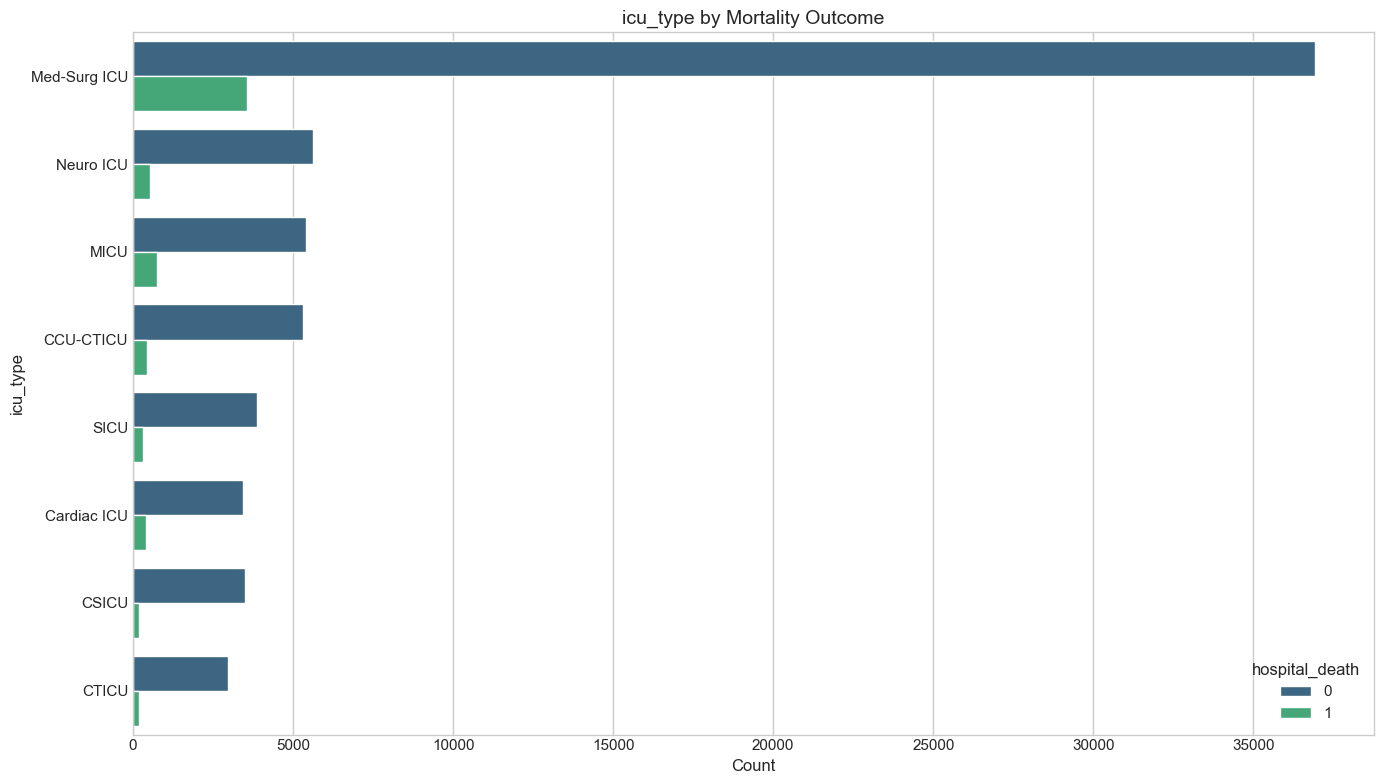

In [63]:
# Visualize categorical features
key_categorical = ['ethnicity', 'apache_2_bodysystem', 'apache_3j_bodysystem', 'icu_type']
viz.plot_categorical_features_by_mortality(X_train_filtered, y_train, key_categorical)

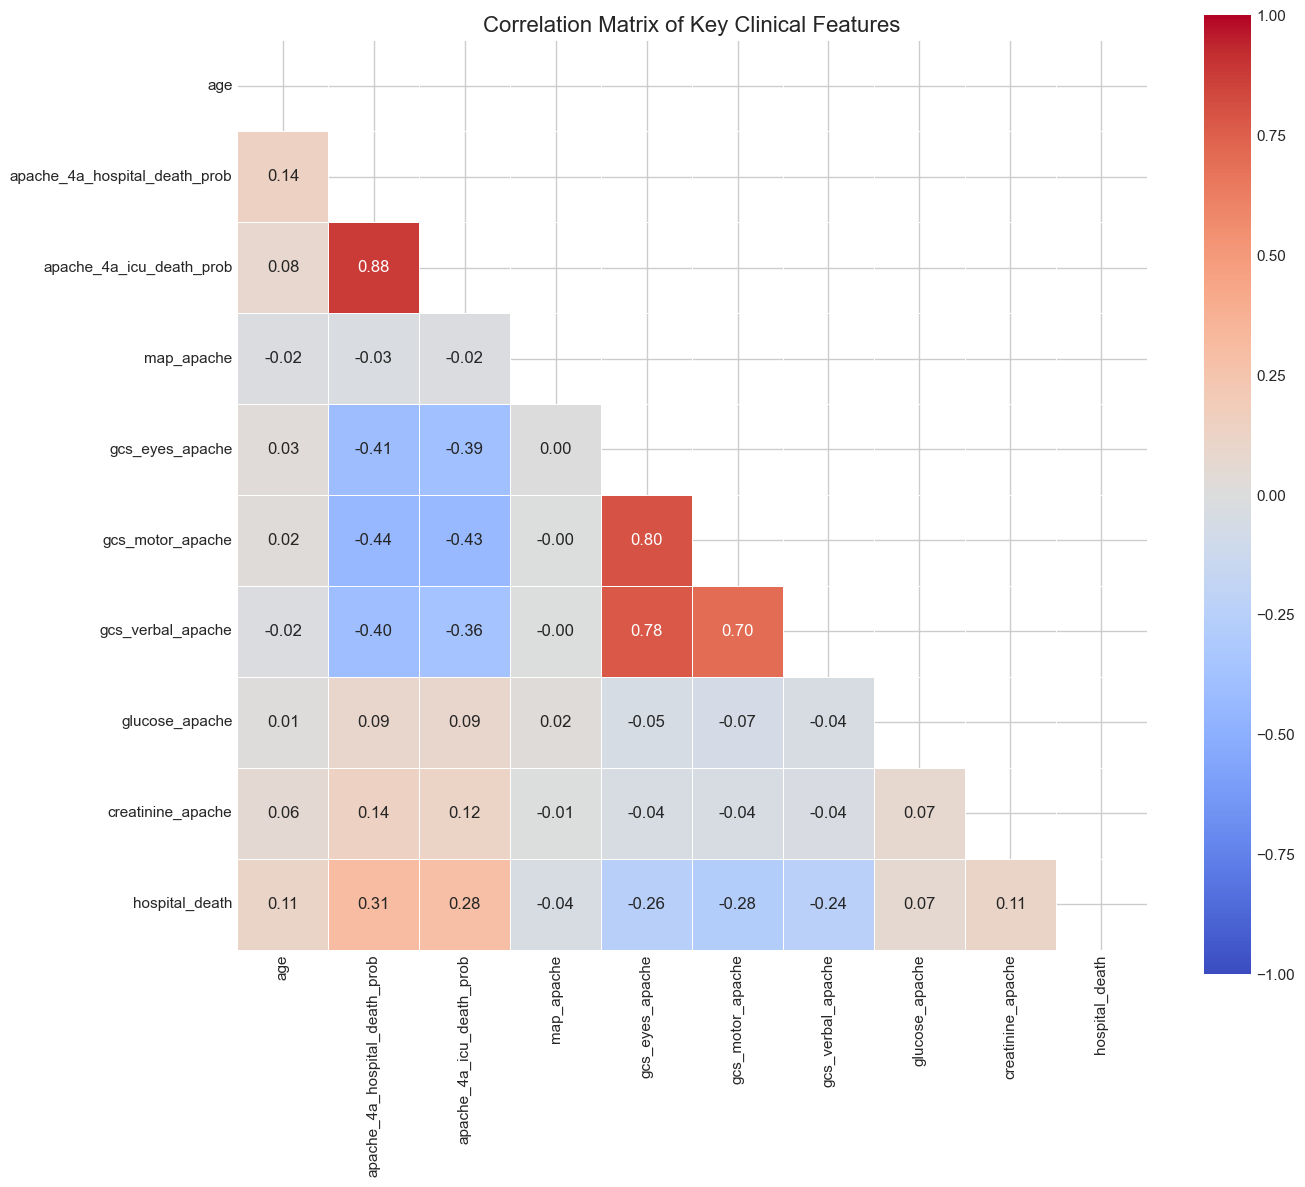

In [64]:
# Correlation analysis
viz.plot_correlation_matrix_of_clinical_features(X_train_filtered, y_train)

## 4. Model Training and Evaluation

In [65]:
# Train models with different imputation strategies
pipelines, scores = mdl.train_and_evaluate_all_imputation_strategies(
    X_train_filtered, X_test_filtered, y_train, y_test,
    numerical_cols, categorical_cols, config.IMPUTATION_STRATEGIES, config.RF_PARAMS
)


Training model with simple imputation...
Evaluation Results - Simple Imputation:
ROC AUC: 0.887
Accuracy: 0.860
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     16760
           1       0.35      0.70      0.46      1583

    accuracy                           0.86     18343
   macro avg       0.66      0.79      0.69     18343
weighted avg       0.92      0.86      0.88     18343


Training model with median imputation...
Evaluation Results - Median Imputation:
ROC AUC: 0.887
Accuracy: 0.862
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     16760
           1       0.35      0.70      0.47      1583

    accuracy                           0.86     18343
   macro avg       0.66      0.79      0.69     18343
weighted avg       0.92      0.86      0.88     18343



18343


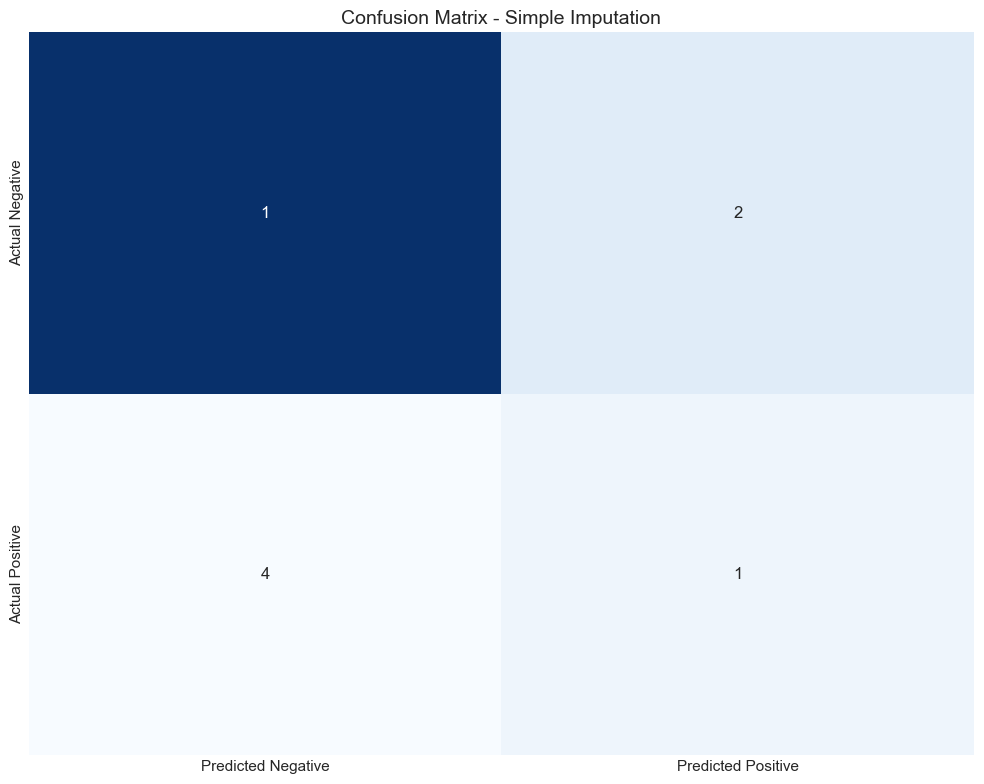

18343


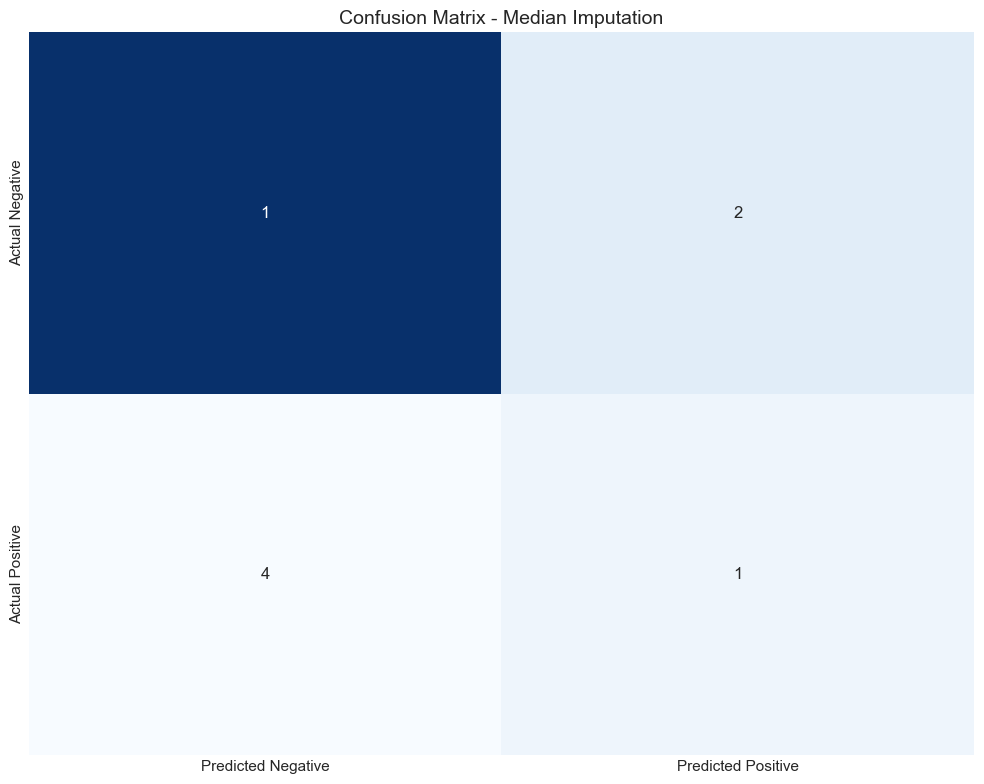

In [77]:
# Create enhanced confusion matrices for all models
for strategy, pipeline in pipelines.items():
    print(len(X_test_filtered))

    y_pred = pipeline.predict(X_test_filtered)
    viz.plot_enhanced_confusion_matrix(y_test, y_pred, strategy)

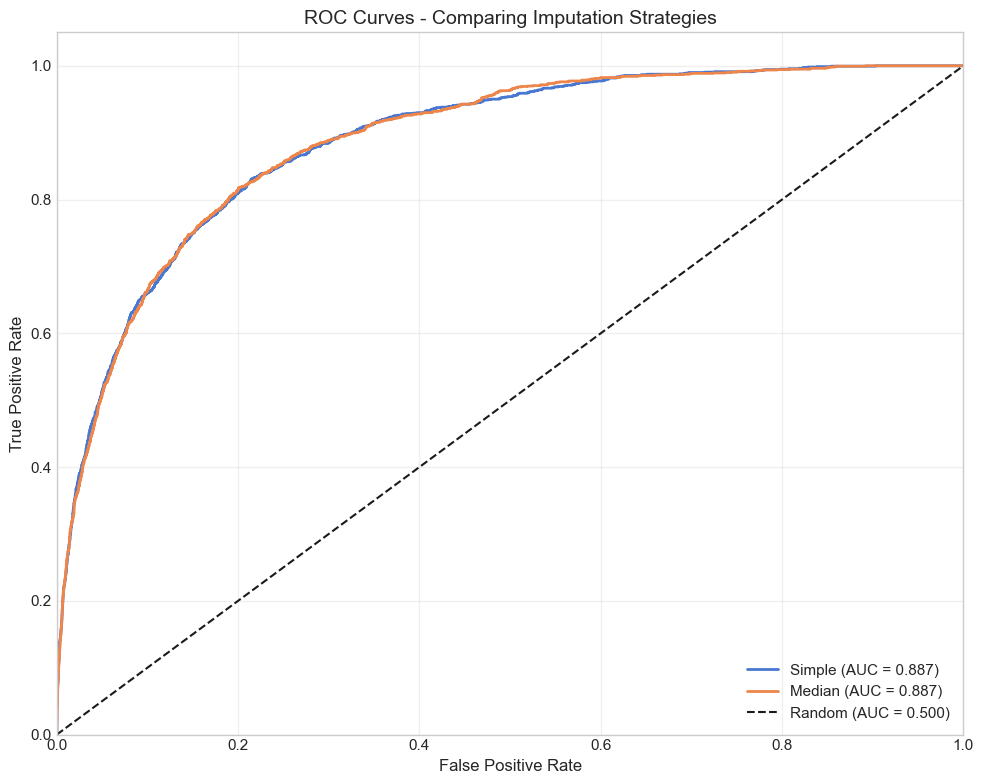

In [67]:
# Compare ROC curves for different imputation strategies
viz.plot_roc_curves_comparison(
    y_test, {strategy: pipeline.predict_proba(X_test_filtered)[:, 1] for strategy, pipeline in pipelines.items()}
)

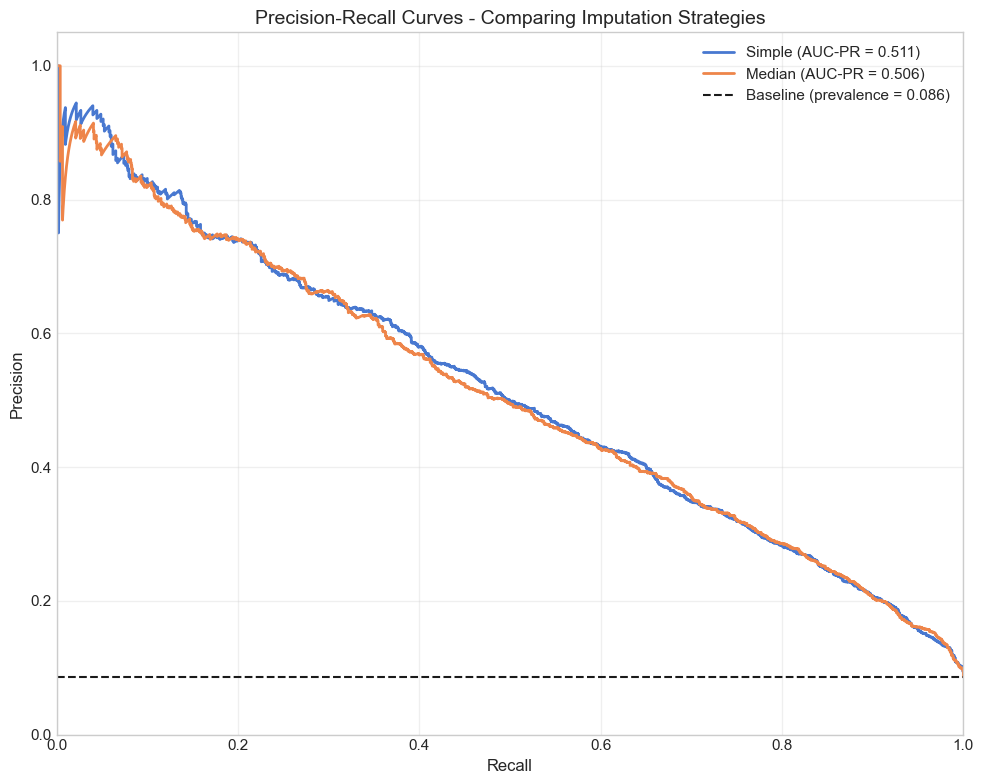

In [68]:
# Compare Precision-Recall curves for different imputation strategies
viz.plot_precision_recall_curves_comparison(
    y_test, {strategy: pipeline.predict_proba(X_test_filtered)[:, 1] for strategy, pipeline in pipelines.items()}
)

In [69]:
# Find the best imputation strategy
comparison_df, best_strategy = utils.compare_models({s: scores[s] for s in config.IMPUTATION_STRATEGIES}, 'roc_auc')

print(f"Best imputation strategy: {best_strategy}")
print(comparison_df)

# Save the best model for later use
best_model = pipelines[best_strategy]
with open(os.path.join(config.MODELS_DIR, f'best_model_{best_strategy}.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

Best imputation strategy: median
         roc_auc
median  0.887291
simple  0.886912


## 5. Feature Importance Analysis

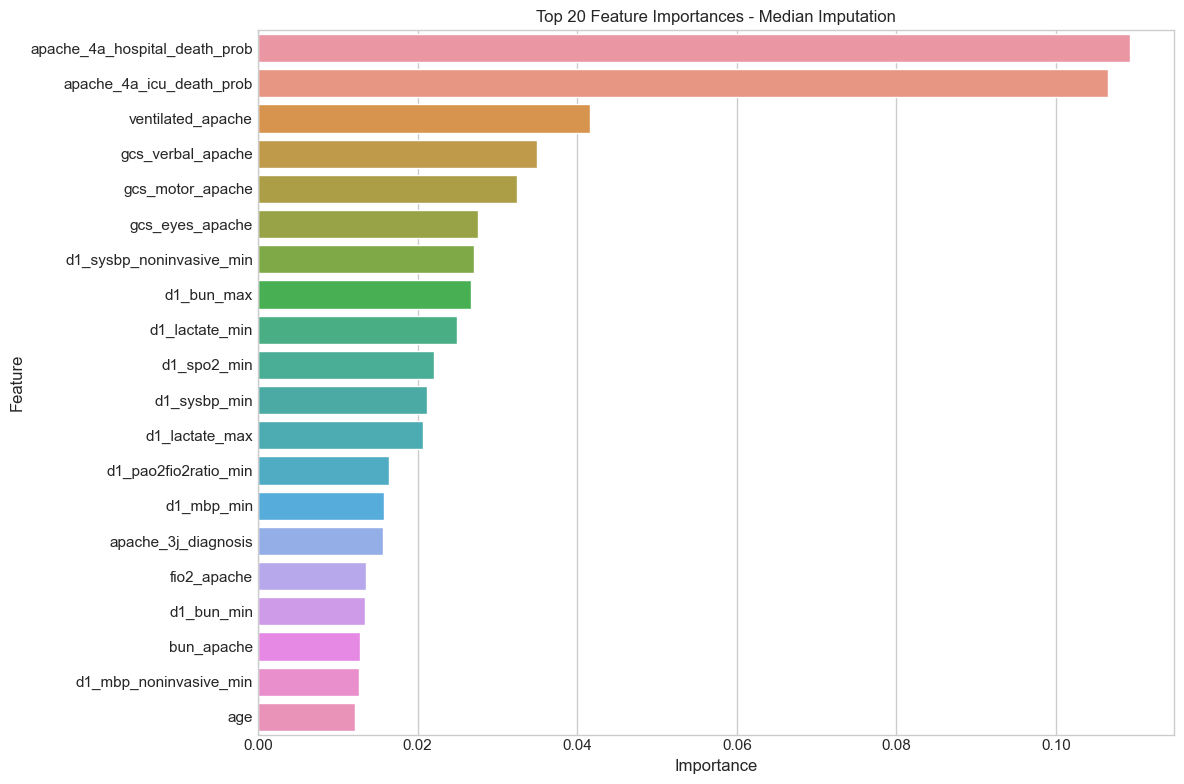

Top 20 most important features:


,Feature,Importance
133,apache_4a_hospital_death_prob,0.109317
134,apache_4a_icu_death_prob,0.106459
37,ventilated_apache,0.041542
23,gcs_verbal_apache,0.035012
21,gcs_motor_apache,0.032494
20,gcs_eyes_apache,0.027534
62,d1_sysbp_noninvasive_min,0.027098
89,d1_bun_max,0.026727
106,d1_lactate_min,0.024884
56,d1_spo2_min,0.022095


In [70]:
# Extract feature names and importances
feature_names = mdl.get_feature_names(pipelines[best_strategy].named_steps['preprocessor'])
feature_importances = pipelines[best_strategy].named_steps['classifier'].feature_importances_

# Plot top 20 features
importance_df = viz.plot_feature_importance(
    feature_names, feature_importances, top_n=20,
    title=f'Top 20 Feature Importances - {best_strategy.capitalize()} Imputation'
)

# Display feature importance table
print("Top 20 most important features:")
display(importance_df.head(20))

In [71]:
# Try to add SHAP analysis if it's available
mdl.analyze_with_shap(best_model, X_test_filtered, feature_names)

SHAP analysis failed: The shape of the shap_values matrix does not match the shape of the provided data matrix.
Continue with other analyses


<Figure size 1200x1000 with 0 Axes>

## 6. Model Comparison with APACHE IV

APACHE IV AUC: 0.850
Our model AUC (on same subset): 0.890
Valid samples for comparison: 16789 out of 18343


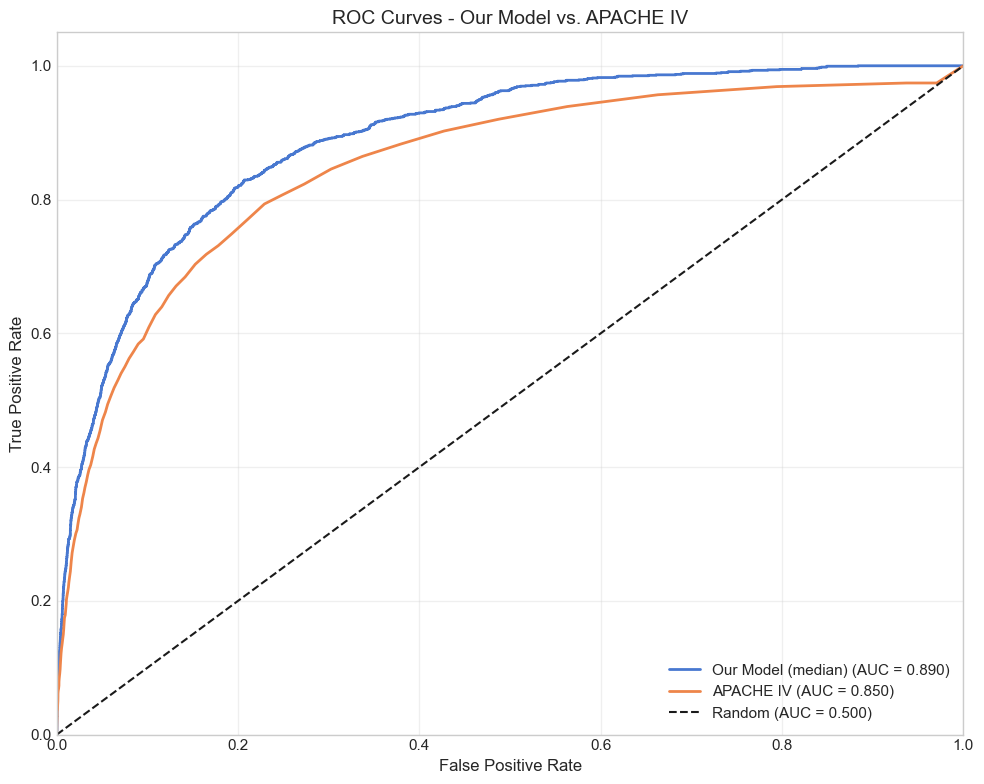

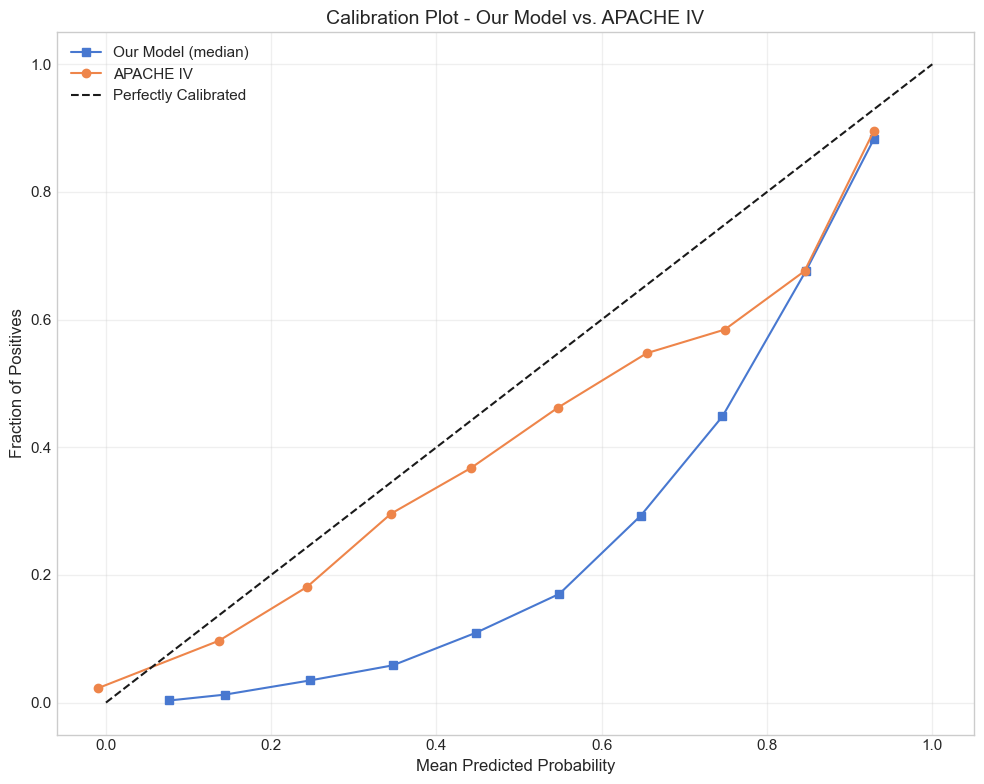

In [72]:
# Compare with APACHE IV prediction if available
apache_result = mdl.compare_with_apache_iv(X_test_filtered, y_test, best_model.predict_proba(X_test_filtered)[:, 1])

if apache_result is not None:
    apache_auc, our_auc = apache_result
    viz.plot_model_vs_apache_comparison(X_test_filtered, y_test, best_model, best_strategy, apache_auc, our_auc)

## 7. Fairness Analysis


Fairness Metrics by Ethnicity:
Fairness Metrics by Ethnicity:


,count,mortality_rate,prediction_rate,auc,selection_rate,true_positive_rate,false_positive_rate
Caucasian,14136,0.086941,0.174095,0.885190,0.174095,0.703824,0.123654
African American,1891,0.080381,0.176626,0.895210,0.176626,0.717105,0.129385
Other/Unknown,868,0.088710,0.169355,0.902835,0.169355,0.701299,0.117573
Hispanic,756,0.097884,0.162698,0.848201,0.162698,0.581081,0.117302
Asian,250,0.084000,0.128000,0.945103,0.128000,0.761905,0.069869
Native American,152,0.065789,0.177632,0.921831,0.177632,0.900000,0.126761


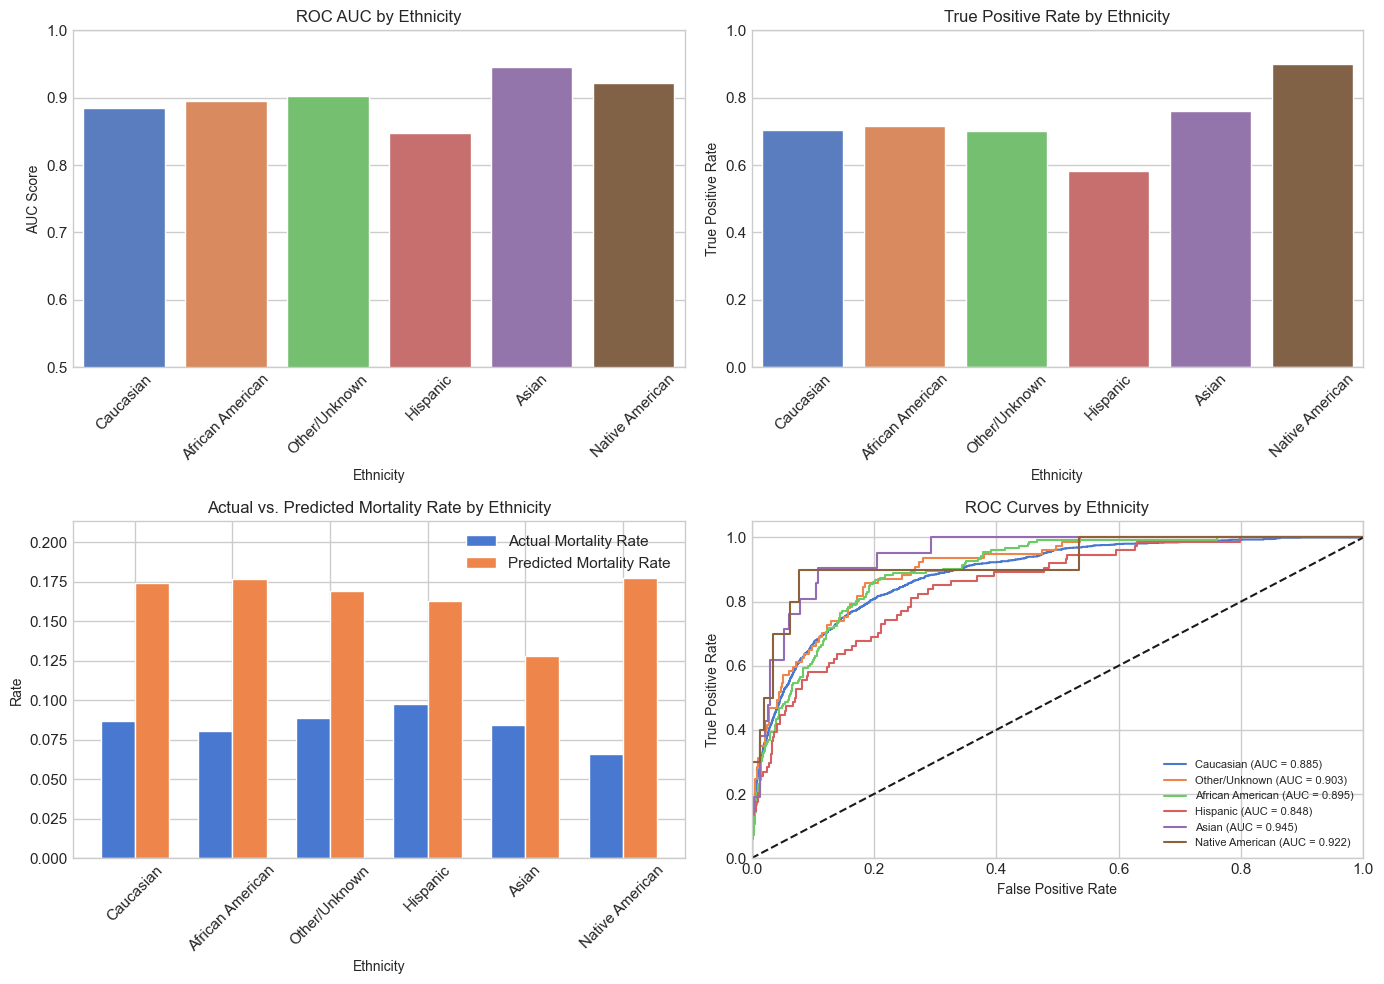

In [73]:
# Analyze model performance across different ethnic groups
best_model = pipelines[best_strategy]
y_pred = best_model.predict(X_test_filtered)
y_proba = best_model.predict_proba(X_test_filtered)[:, 1]

fairness_df, metrics_by_ethnicity = mdl.analyze_fairness_by_ethnicity(
    X_test_filtered, y_test, y_pred, y_proba
)

if fairness_df is not None:
    print("Fairness Metrics by Ethnicity:")
    display(fairness_df)
    
    # Plot fairness metrics
    viz.plot_fairness_metrics(fairness_df, metrics_by_ethnicity)

## 8. Analysis by Body System

Model Performance by Body System:


,mortality_rate,count,auc,precision,recall,f1,prediction_rate
Metabolic,0.014696,1497,0.950909,0.285714,0.363636,0.320000,0.018704
Haematologic,0.134752,141,0.921484,0.520000,0.684211,0.590909,0.177305
Undefined diagnoses,0.015852,757,0.920134,0.222222,0.166667,0.190476,0.011889
Trauma,0.052097,787,0.907507,0.285714,0.682927,0.402878,0.124524
Neurologic,0.073294,2374,0.895502,0.391975,0.729885,0.510040,0.136479
Cardiovascular,0.107271,7812,0.889536,0.361378,0.763723,0.490609,0.226703
Renal/Genitourinary,0.052301,478,0.882649,0.285714,0.560000,0.378378,0.102510
Gastrointestinal,0.081875,1771,0.830182,0.355263,0.558621,0.434316,0.128741
Respiratory,0.118557,2328,0.823122,0.305281,0.670290,0.419501,0.260309
Undefined Diagnoses,0.057971,69,0.792308,0.222222,0.500000,0.307692,0.130435


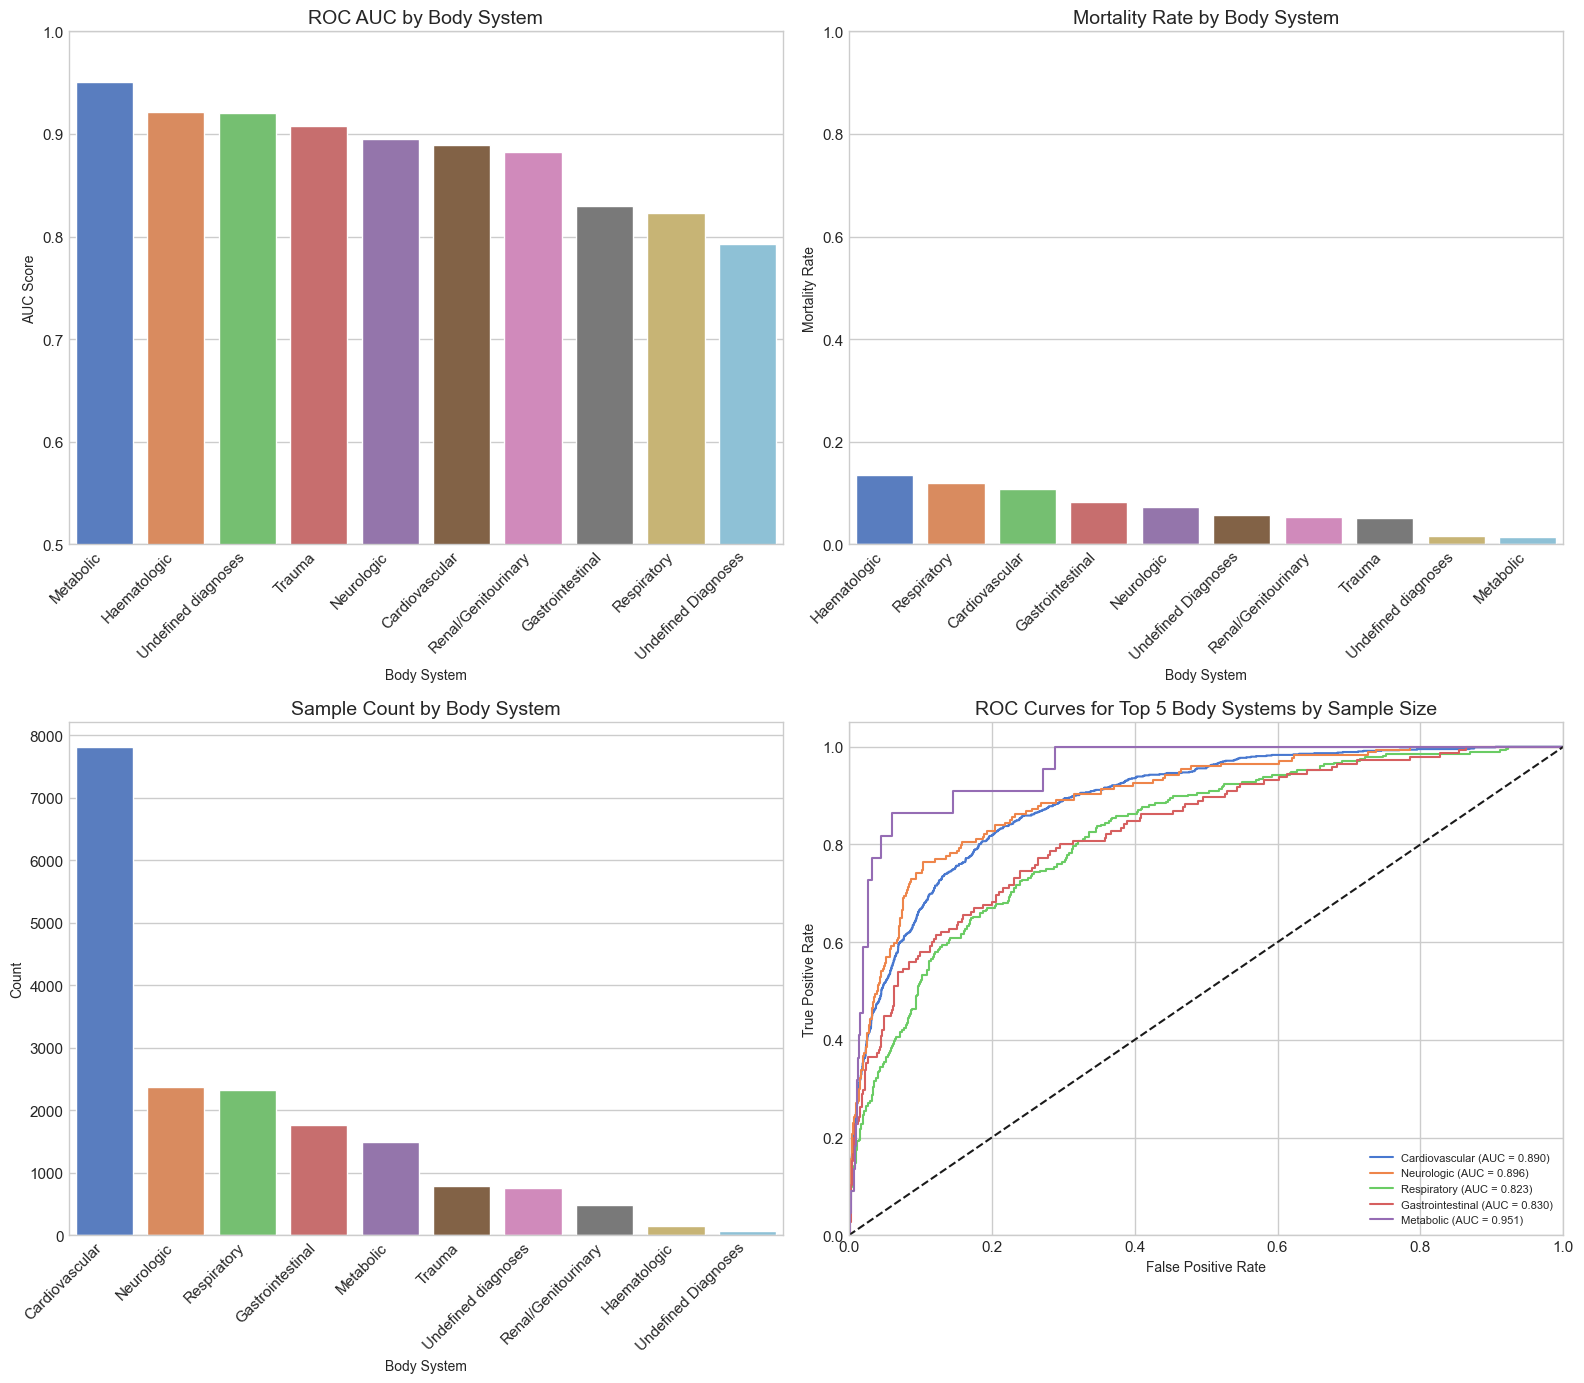

In [74]:
# Get a high-level overview of body system performance
body_system_df, body_system_metrics = mdl.analyze_performance_by_body_system(
    X_test_filtered, y_test, best_model
)

if body_system_df is not None:
    print("Model Performance by Body System:")
    display(body_system_df)
    
    # Plot performance by body system
    viz.plot_performance_by_body_system(body_system_df, body_system_metrics)

## 9. Additional Analysis: In-Depth Body System Modeling


Analyzing body system: Cardiovascular
Training samples: 31004, Test samples: 7812
Evaluation Results - Body System: Cardiovascular:
ROC AUC: 0.892
Accuracy: 0.870
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      6974
           1       0.43      0.68      0.53       838

    accuracy                           0.87      7812
   macro avg       0.70      0.79      0.73      7812
weighted avg       0.90      0.87      0.88      7812


Analyzing body system: Gastrointestinal
Training samples: 7255, Test samples: 1771
Evaluation Results - Body System: Gastrointestinal:
ROC AUC: 0.824
Accuracy: 0.925
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1626
           1       0.58      0.32      0.41       145

    accuracy                           0.93      1771
   macro avg       0.76      0.65      0.69      1771
weighted avg       0.91 

C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

Evaluation Results - Body System: Metabolic:
ROC AUC: 0.927
Accuracy: 0.985
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1475
           1       0.00      0.00      0.00        22

    accuracy                           0.99      1497
   macro avg       0.49      0.50      0.50      1497
weighted avg       0.97      0.99      0.98      1497


Analyzing body system: Renal/Genitourinary
Training samples: 1982, Test samples: 478
Evaluation Results - Body System: Renal/Genitourinary:
ROC AUC: 0.834
Accuracy: 0.950
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       453
           1       0.60      0.12      0.20        25

    accuracy                           0.95       478
   macro avg       0.78      0.56      0.59       478
weighted avg       0.94      0.95      0.93       478


Analyzing body system: Undefined diagnoses
Training

C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

Evaluation Results - Body System: Undefined diagnoses:
ROC AUC: 0.908
Accuracy: 0.984
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       745
           1       0.00      0.00      0.00        12

    accuracy                           0.98       757
   macro avg       0.49      0.50      0.50       757
weighted avg       0.97      0.98      0.98       757


Analyzing body system: Undefined Diagnoses
Training samples: 277, Test samples: 69
Evaluation Results - Body System: Undefined Diagnoses:
ROC AUC: 0.692
Accuracy: 0.942
Classification Report:


...

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        65
           1       0.00      0.00      0.00         4

    accuracy                           0.94        69
   macro avg       0.47      0.50      0.49        69
weighted avg       0.89      0.94      0.91        69


Analyzing body system: Haematologic
Training samples: 497, Test samples: 141
Evaluation Results - Body System: Haematologic:
ROC AUC: 0.862
Accuracy: 0.865
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       122
           1       0.00      0.00      0.00        19

    accuracy                           0.87       141
   macro avg       0.43      0.50      0.46       141
weighted avg       0.75      0.87      0.80       141


AUC Scores for Models Trained Specifically for Each Body System:


C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

,AUC
Metabolic,0.926502
Neurologic,0.907717
Undefined diagnoses,0.907606
Trauma,0.892238
Cardiovascular,0.892061
Haematologic,0.861519
Renal/Genitourinary,0.834437
Gastrointestinal,0.824494
Respiratory,0.824113
Undefined Diagnoses,0.692308



Comparing Overall vs. Specialized Models by Body System:


,Overall Model AUC,Specialized Model AUC,Improvement
Neurologic,0.895502,0.907717,0.012215
Cardiovascular,0.889536,0.892061,0.002525
Respiratory,0.823122,0.824113,0.000991
Gastrointestinal,0.830182,0.824494,-0.005688
Undefined diagnoses,0.920134,0.907606,-0.012528
Trauma,0.907507,0.892238,-0.015268
Metabolic,0.950909,0.926502,-0.024407
Renal/Genitourinary,0.882649,0.834437,-0.048212
Haematologic,0.921484,0.861519,-0.059965
Undefined Diagnoses,0.792308,0.692308,-0.100000


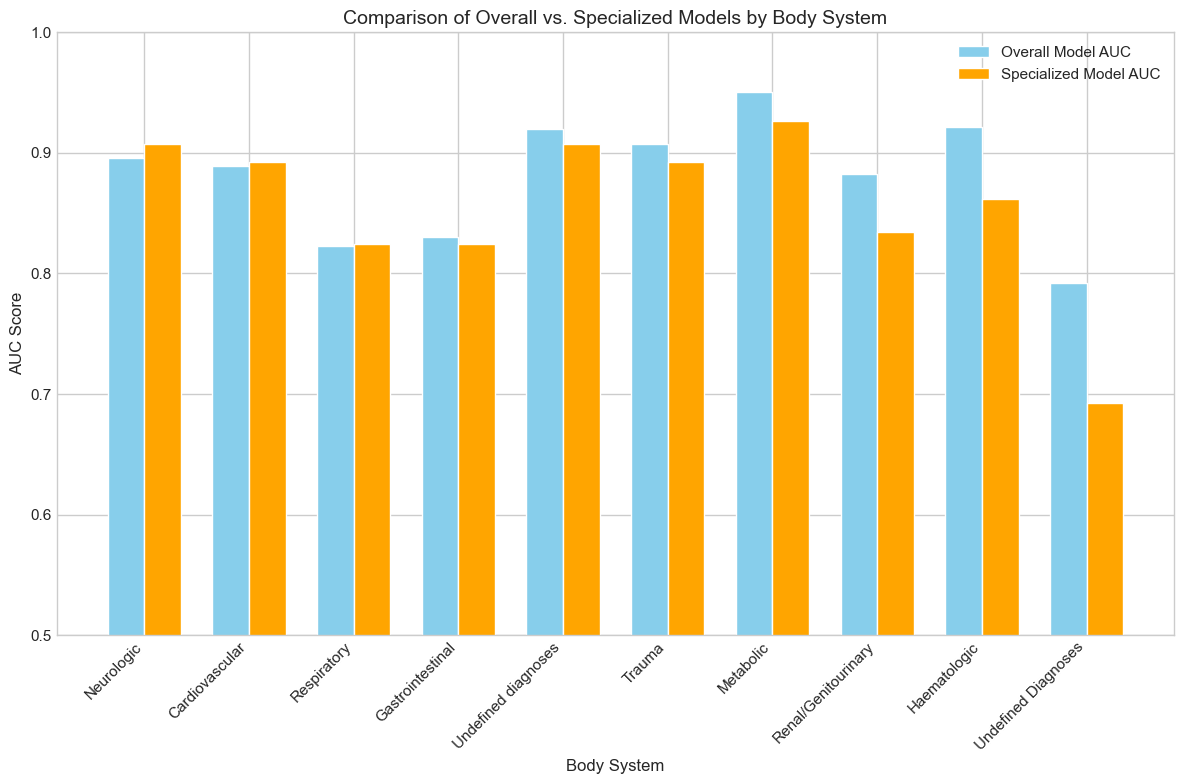


Top 10 important features for Metabolic:


,Feature,Importance
133,apache_4a_hospital_death_prob,0.073337
134,apache_4a_icu_death_prob,0.049048
56,d1_spo2_min,0.024305
90,d1_bun_min,0.024166
62,d1_sysbp_noninvasive_min,0.020346
126,d1_arterial_pco2_min,0.020242
103,d1_inr_max,0.019409
130,d1_arterial_po2_min,0.017559
100,d1_hemaglobin_min,0.016658
102,d1_hematocrit_min,0.016076


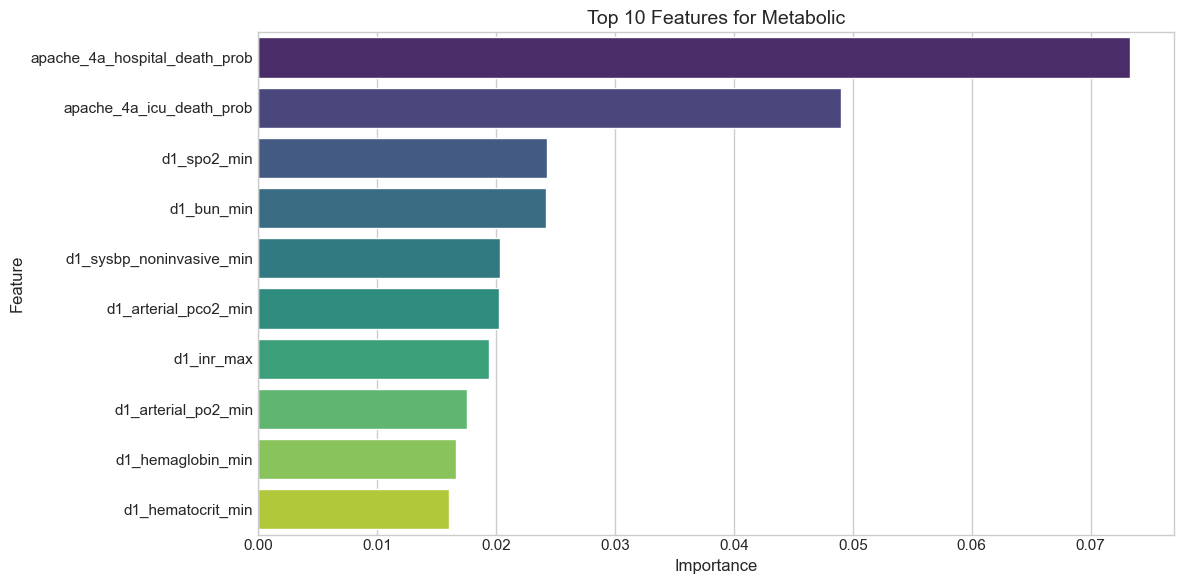

In [75]:
# Perform a more detailed analysis by body system
body_system_results = mdl.analyze_by_body_system(
    X_train_filtered, y_train, 
    X_test_filtered, y_test, 
    numerical_cols, categorical_cols, 
    best_strategy
)

if body_system_results is not None and len(body_system_results) > 0:
    viz.plot_body_system_analysis_results(body_system_results, body_system_df, feature_names)

## 10. Finding Optimal Classification Threshold

Optimal threshold: 0.633 (F1: 0.503)
Balanced threshold: 0.646 (Precision = 0.497, Recall = 0.497)

Performance with optimal threshold (maximizing F1):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     16760
           1       0.48      0.52      0.50      1583

    accuracy                           0.91     18343
   macro avg       0.72      0.73      0.73     18343
weighted avg       0.91      0.91      0.91     18343


Performance with balanced threshold (equal precision and recall):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     16760
           1       0.50      0.50      0.50      1583

    accuracy                           0.91     18343
   macro avg       0.72      0.72      0.72     18343
weighted avg       0.91      0.91      0.91     18343



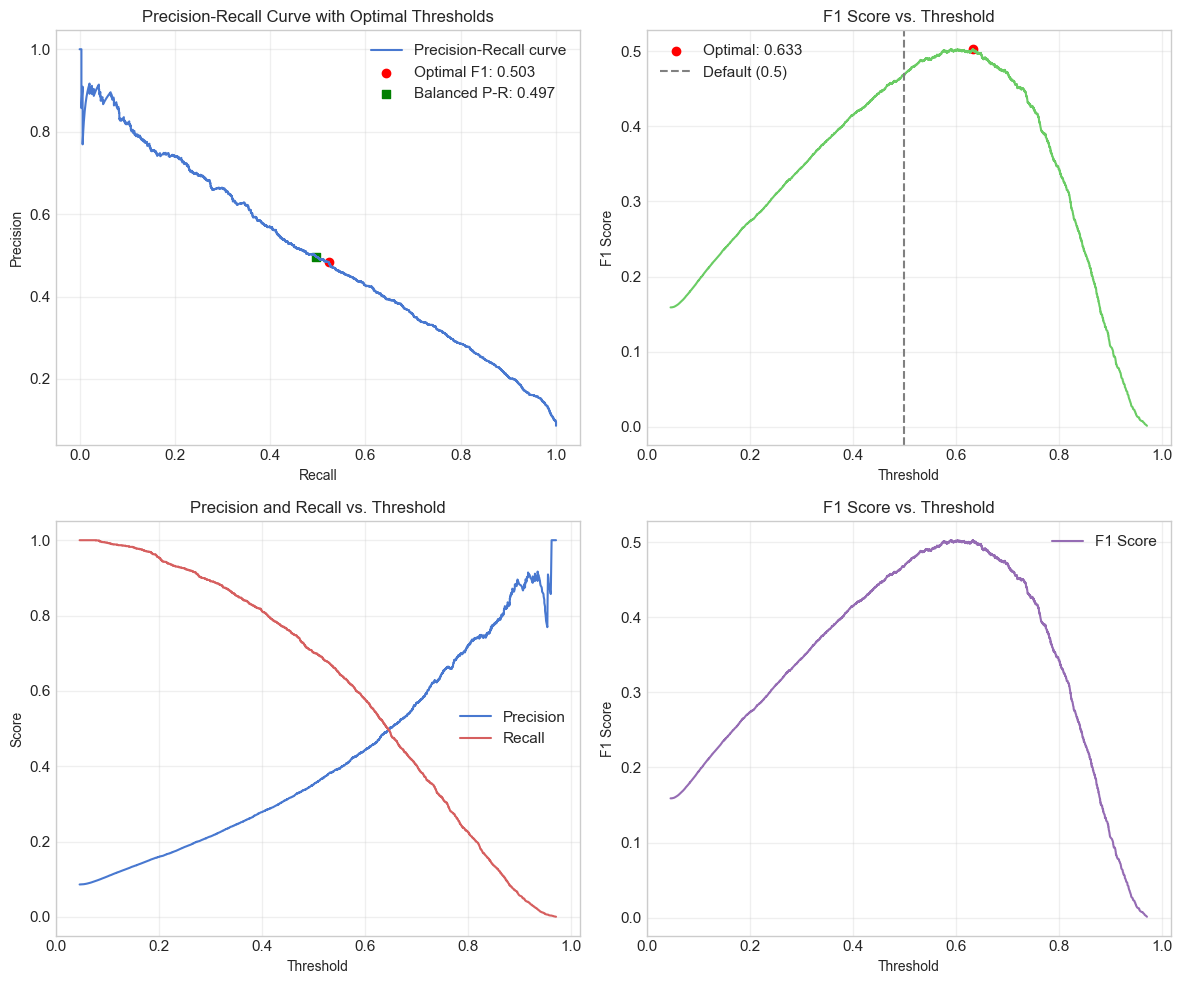

In [76]:
# Find the optimal classification threshold for our best model
thresholds_analysis = mdl.analyze_classification_thresholds(best_model, X_test_filtered, y_test)
viz.plot_threshold_analysis_results(thresholds_analysis)